In [42]:
import xarray as xr
import numpy as np
import sys,os
from pathlib import Path
WAVE_TOOLS_PATH = Path("/work/mh1498/m301257/wave_tools")
sys.path.insert(0, str(WAVE_TOOLS_PATH.parent))
from wave_tools import calculate_cross_spectrum, quick_cross_spectrum,remove_annual_cycle
from wave_tools.utils import  get_curve
from  wave_tools.plotting import get_cckw_envelope_curve,setup_map_axes,set_axis_for_wave 
import cmaps

In [24]:
# ============ 加载降水数据 ============

def load_precipitation_data(experiment='cntl', data_dir='/work/mh1498/m301257/data_origin', 
                           chunks={'time': 100}):
    """
    加载降水数据 (使用 chunking 避免内存溢出)
    
    Parameters:
    -----------
    experiment : str
        实验名称，可选: 'cntl', 'p4k', '4co2'
    data_dir : str
        数据目录
    chunks : dict
        数据分块参数，默认按时间维度每100个时间步分一块
    
    Returns:
    --------
    xr.DataArray
        降水数据 (lazy loading)
    """
    # 构建文件路径
    file_path = os.path.join(data_dir, f'pr_{experiment}_2deg_interp.nc')
    
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"未找到实验 {experiment} 的降水数据文件: {file_path}")
    
    print(f"📂 加载数据: {file_path}")
    
    # 使用 chunks 参数实现 lazy loading
    try:
        pr = xr.open_dataarray(file_path, engine='netcdf4', chunks=chunks)
    except:
        try:
            pr = xr.open_dataarray(file_path, engine='h5netcdf', chunks=chunks)
        except:
            pr = xr.open_dataarray(file_path, chunks=chunks)
    
    print(f"✅ 数据加载成功 (lazy loading)")
    print(f"   形状: {pr.shape}")
    print(f"   维度: {pr.dims}")
    print(f"   数据块: {pr.chunks}")
    if hasattr(pr, 'time'):
        print(f"   时间范围: {pr.time.values[0]} to {pr.time.values[-1]}")
    
    # 估算数据大小
    data_size_gb = pr.nbytes / 1024**3
    print(f"   估算数据大小: {data_size_gb:.2f} GB")
    
    return pr


def load_all_precipitation_data(chunks={'time': 100}):
    """
    加载所有实验的降水数据 (使用 lazy loading)
    
    Parameters:
    -----------
    chunks : dict
        数据分块参数
    
    Returns:
    --------
    dict
        包含所有实验降水数据的字典
    """
    print("\n" + "="*60)
    print("加载所有降水数据")
    print("="*60)
    
    
    experiments = ['cntl', 'p4k', '4co2']
    pr_data = {}
    
    for exp in experiments:
        try:
            print(f"\n加载 {exp.upper()}...")
            pr = load_precipitation_data(exp, chunks=chunks)
            pr_data[exp] = pr
        except Exception as e:
            print(f"❌ 错误: {e}")
    
    print(f"\n{'='*60}")
    print(f"✅ 成功加载 {len(pr_data)} 个实验的数据")
    print(f"{'='*60}")
   
    return pr_data
# 加载所有实验的降水数据
pr_data = load_all_precipitation_data()


加载所有降水数据

加载 CNTL...
📂 加载数据: /work/mh1498/m301257/data_origin/pr_cntl_2deg_interp.nc
✅ 数据加载成功 (lazy loading)
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   数据块: ((100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 14), (15,), (180,))
   时间范围: 1980-01-01T00:00:00.000000000 to 1993-12-31T00:00:00.000000000
   估算数据大小: 0.10 GB

加载 P4K...
📂 加载数据: /work/mh1498/m301257/data_origin/pr_p4k_2deg_interp.nc
✅ 数据加载成功 (lazy loading)
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   数据块: ((100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 14), (15,), (180,))
   时间范围: 1980-01-01T00:00

In [25]:
def _ocean():
    fraction = xr.open_dataarray(r'../processed_data/land_mask_2deg.nc')
    return fraction == 0
ocean_mask = _ocean()

In [26]:
div_cntl = xr.open_dataset(r'/work/mh1498/m301257/3D_data/divergence_2d_plvls/div_pressure_levels_cntl.nc')
div_p4k = xr.open_dataset(r'/work/mh1498/m301257/3D_data/divergence_2d_plvls/div_pressure_levels_p4k.nc')
div_4co2 = xr.open_dataset(r'/work/mh1498/m301257/3D_data/divergence_2d_plvls/div_pressure_levels_4co2.nc')

In [27]:
# ============ 计算不同气压层的散度与降水的交叉谱 ============
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# 定义要分析的气压层
pressure_levels = [250, 500, 850]  # hPa

# 存储所有结果
crossspectrum_results = {}

for exp_name in ['cntl', 'p4k', '4co2']:
    print(f"\n{'='*60}")
    print(f"  处理 {exp_name.upper()}...")
    print(f"{'='*60}")
    
    # 获取降水数据
    pr_raw = pr_data[exp_name]
    pr_raw = pr_raw.where(ocean_mask,drop=True)
    print(pr_raw.shape)
    # 获取散度数据集
    if exp_name == 'cntl':
        div_dataset = div_cntl
    elif exp_name == 'p4k':
        div_dataset = div_p4k
    else:
        div_dataset = div_4co2
    
    # 初始化该实验的结果字典
    crossspectrum_results[exp_name] = {}
    
    # 循环处理每个气压层
    for plev in pressure_levels:
        print(f"\n  --- 气压层: {plev} hPa ---")
        
        # 选择特定气压层的散度数据
        div_raw = div_dataset['__xarray_dataarray_variable__'].sel(plev=plev)
        
        # 检查并对齐网格
        # 如果经度维度不同，将散度数据插值到降水数据的网格上
        if len(pr_raw.lon) != len(div_raw.lon):
            print(f"    对齐网格: pr_lon={len(pr_raw.lon)}, div_lon={len(div_raw.lon)}")
            div_raw = div_raw.interp(lon=pr_raw.lon, method='linear')
        
        # 如果纬度维度不同，也进行插值
        if len(pr_raw.lat) != len(div_raw.lat):
            print(f"    对齐网格: pr_lat={len(pr_raw.lat)}, div_lat={len(div_raw.lat)}")
            div_raw = div_raw.interp(lat=pr_raw.lat, method='linear')
        
        # 应用海洋掩膜
        pr_masked = pr_raw.where(ocean_mask)
        div_masked = div_raw.where(ocean_mask)
        
        # 先填充NaN值（用0填充陆地区域）
        pr_masked = pr_masked.fillna(0)
        div_masked = div_masked.fillna(0)
        
        # 去除年循环（计算异常值）
        print(f"    去除年循环...")
        pr_ano = remove_annual_cycle(pr_masked)
        div_ano = remove_annual_cycle(div_masked)
        
        print(f"    数据统计:")
        print(f"      pr_ano: shape={pr_ano.shape}, range=[{np.min(pr_ano.values):.6e}, {np.max(pr_ano.values):.6e}]")
        print(f"      div_ano: shape={div_ano.shape}, range=[{np.min(div_ano.values):.6e}, {np.max(div_ano.values):.6e}]")
        
        # 计算交叉谱
        print(f"    计算交叉谱...")
        result = calculate_cross_spectrum(
            pr_ano, div_ano, 
            segLen=96, 
            segOverLap=-65,
            symmetry='symm',
            return_xarray=True
        )
        
        # 提取并存储结果
        if result is None:
            print(f"    ✗ 交叉谱计算失败！")
            continue
        
        stc_da = result['STC']
        
        print(f"    ✓ 交叉谱计算成功！")
        print(f"      STC shape: {stc_da.shape}")
        print(f"      波数范围: {result['wave'].min():.2f} ~ {result['wave'].max():.2f}")
        print(f"      频率范围: {result['freq'].min():.4f} ~ {result['freq'].max():.4f}")
        
        # 存储该气压层的结果
        crossspectrum_results[exp_name][plev] = {
            'STC': stc_da,
            'freq': result['freq'],
            'wave': result['wave'],
            'nseg': result['nseg'],
            'dof': result['dof'],
            'p': result['p'],
            'prob_coh2': result['prob_coh2']
        }

print("\n" + "="*60)
print("✅ 所有实验和气压层的交叉谱计算完成！")
print("="*60)


  处理 CNTL...
(5114, 15, 167)

  --- 气压层: 250 hPa ---
    对齐网格: pr_lon=167, div_lon=180
    对齐网格: pr_lat=15, div_lat=17
    去除年循环...
    数据统计:
      pr_ano: shape=(5114, 15, 167), range=[-5.275542e-04, 6.902297e-03]
      div_ano: shape=(5114, 15, 167), range=[-7.998894e-05, 6.782875e-05]
    计算交叉谱...
    ✓ 交叉谱计算成功！
      STC shape: (8, 49, 167)
      波数范围: -83.00 ~ 83.00
      频率范围: 0.0000 ~ 0.5000

  --- 气压层: 500 hPa ---
    对齐网格: pr_lon=167, div_lon=180
    对齐网格: pr_lat=15, div_lat=17
    去除年循环...
    数据统计:
      pr_ano: shape=(5114, 15, 167), range=[-5.275542e-04, 6.902297e-03]
      div_ano: shape=(5114, 15, 167), range=[-6.112691e-05, 5.024366e-05]
    计算交叉谱...
    ✓ 交叉谱计算成功！
      STC shape: (8, 49, 167)
      波数范围: -83.00 ~ 83.00
      频率范围: 0.0000 ~ 0.5000

  --- 气压层: 850 hPa ---
    对齐网格: pr_lon=167, div_lon=180
    对齐网格: pr_lat=15, div_lat=17
    去除年循环...
    数据统计:
      pr_ano: shape=(5114, 15, 167), range=[-5.275542e-04, 6.902297e-03]
      div_ano: shape=(5114, 15, 167), 

In [28]:
# ============ 访问结果数据 ============

# 查看可用的数据结构
print("可用的实验:", list(crossspectrum_results.keys()))
print("\n每个实验的气压层:", list(crossspectrum_results['cntl'].keys()))
print("\n每个气压层包含的数据:")
for key in crossspectrum_results['cntl'][250].keys():
    data = crossspectrum_results['cntl'][250][key]
    if hasattr(data, 'shape'):
        print(f"  {key}: shape = {data.shape}")
    else:
        print(f"  {key}: {data}")

# 示例：访问特定实验和气压层的交叉谱数据
print("\n" + "="*60)
print("示例：获取 CNTL 实验 500 hPa 的交叉谱数据")
print("="*60)
stc_cntl_500 = crossspectrum_results['cntl'][500]['STC']
freq = crossspectrum_results['cntl'][500]['freq']
wave = crossspectrum_results['cntl'][500]['wave']

print(f"STC 数据类型: {type(stc_cntl_500)}")
print(f"STC 形状: {stc_cntl_500.shape}")
print(f"STC 维度: {stc_cntl_500.dims}")
print(f"\n频率范围: {freq.min():.4f} - {freq.max():.4f} cpd")
print(f"波数范围: {wave.min():.0f} - {wave.max():.0f}")

可用的实验: ['cntl', 'p4k', '4co2']

每个实验的气压层: [250, 500, 850]

每个气压层包含的数据:
  STC: shape = (8, 49, 167)
  freq: shape = (49,)
  wave: shape = (167,)
  nseg: 168
  dof: 448.056
  p: shape = (6,)
  prob_coh2: shape = (6,)

示例：获取 CNTL 实验 500 hPa 的交叉谱数据
STC 数据类型: <class 'xarray.core.dataarray.DataArray'>
STC 形状: (8, 49, 167)
STC 维度: ('component', 'frequency', 'wavenumber')

频率范围: 0.0000 - 0.5000 cpd
波数范围: -83 - 83


In [29]:
# ============ 定义绘图所需的参数和变量 ============

# 实验名称和标题
exp_names = ['cntl', 'p4k', '4co2']
exp_titles = ['CNTL', 'P4K', '4CO2']

# 颜色映射
cmap_to_use = 'RdBu_r'  # 可以根据需要更改为其他colormap，如 'viridis', 'plasma', 'coolwarm' 等

# coherence squared 阈值（用于掩蔽矢量场）
coh2_threshold = 0.2  # 可以根据需要调整，一般在0.1-0.3之间

# 物理常数
s2d = 86400  # 每天的秒数
re = 6.371e6  # 地球半径（米）

# 图片保存目录
FIG_SAVE_DIR = '/work/mh1498/m301257/figures/'

# 确保图片保存目录存在
import os
os.makedirs(FIG_SAVE_DIR, exist_ok=True)

print("✅ 绘图参数已设置:")
print(f"   实验: {exp_names}")
print(f"   标题: {exp_titles}")
print(f"   Colormap: {cmap_to_use}")
print(f"   Coherence² 阈值: {coh2_threshold}")
print(f"   图片保存目录: {FIG_SAVE_DIR}")

✅ 绘图参数已设置:
   实验: ['cntl', 'p4k', '4co2']
   标题: ['CNTL', 'P4K', '4CO2']
   Colormap: RdBu_r
   Coherence² 阈值: 0.2
   图片保存目录: /work/mh1498/m301257/figures/



绘制 850 hPa 气压层的交叉谱图
✅ 图片已保存: /work/mh1498/m301257/figures/cross_spectrum_pr_div_850hpa_99%.png


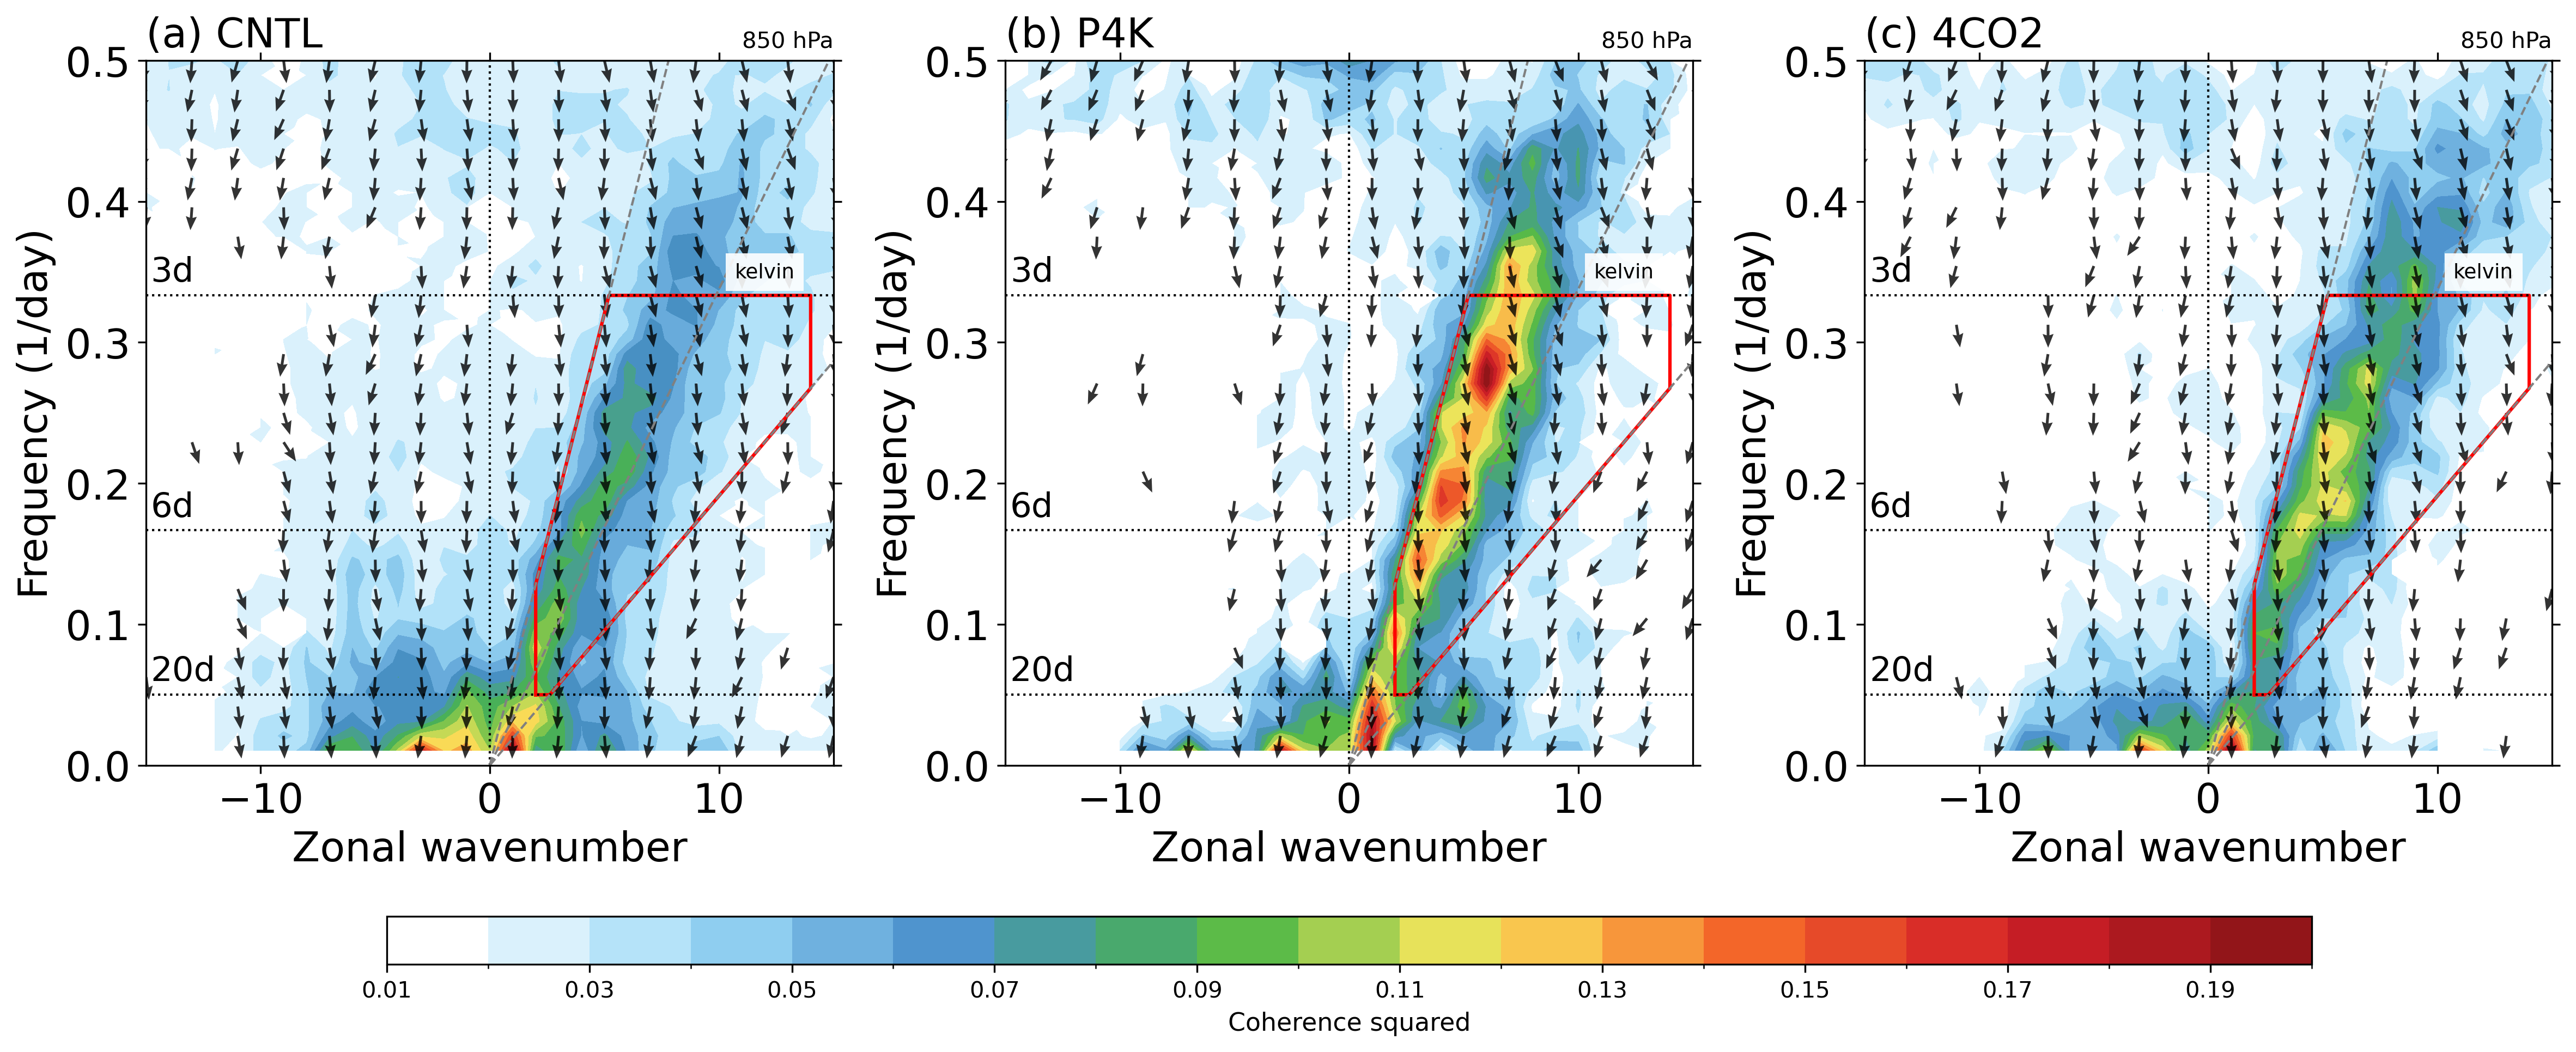


✅ 所有气压层的图片生成完成！


In [44]:
# ============ 为所有气压层生成指定样式的交叉谱图 ============
coh2_threshold = 0.01
# 循环处理所有气压层
for PLEV in [850]:
    print(f"\n{'='*60}")
    print(f"绘制 {PLEV} hPa 气压层的交叉谱图")
    print(f"{'='*60}")
    
    # 创建3个子图
    fig, axes = plt.subplots(1, 3, figsize=(16, 8), dpi=300)
    plt.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.15, wspace=0.25)
    plt.rcParams.update({'font.size': 10})

    for idx, (exp_name, exp_title, ax) in enumerate(zip(exp_names, exp_titles, axes)):
        plt.sca(ax)

        # 获取当前实验和气压层的结果
        stc = crossspectrum_results[exp_name][PLEV]['STC']
        zonalwnum = crossspectrum_results[exp_name][PLEV]['wave']
        freq = crossspectrum_results[exp_name][PLEV]['freq']

        # 获取coherence squared数据
        try:
            coh2_data = stc.sel(component='COH2')
        except:
            coh2_data = stc.isel(component=2)
        coh2_data_masked = coh2_data.where(coh2_data >= coh2_threshold)
        # 绘制coherence squared的等高线图
        contourf = coh2_data_masked.plot.contourf(
            ax=ax,
            cmap=cmaps.WhiteBlueGreenYellowRed,
            levels=21,
            add_colorbar=False,
            add_labels=False,
            extend='neither'
        )

        # 准备矢量场数据
        skip = 2
        wave_sub = zonalwnum[::skip]
        freq_sub = freq[::skip]
        
        # 获取V1和V2分量
        try:
            u_sub = stc.sel(component='V1').values[::skip, ::skip]
            v_sub = stc.sel(component='V2').values[::skip, ::skip]
            coh2_sub = stc.sel(component='COH2').values[::skip, ::skip]
        except:
            u_sub = stc.isel(component=0).values[::skip, ::skip]
            v_sub = stc.isel(component=1).values[::skip, ::skip]
            coh2_sub = stc.isel(component=2).values[::skip, ::skip]

        # 创建掩蔽
        mask = coh2_sub < coh2_threshold
        u_masked = np.where(mask, np.nan, u_sub)
        v_masked = np.where(mask, np.nan, v_sub)

        # 添加矢量场
        q = ax.quiver(
            wave_sub, freq_sub,
            u_masked, v_masked,
            scale=30, headwidth=4, headlength=5, 
            width=0.004, alpha=0.8
        )

        # 设置标题
        ax.set_title(f'({chr(97 + idx)}) {exp_title}', fontsize=18, loc='left')
        ax.set_title(f'{PLEV} hPa', fontsize=10, loc='right')

        # 设置坐标轴
        ax.set_ylabel('Frequency (1/day)', fontsize=18)
        ax.set_xlabel('Zonal wavenumber', fontsize=18)
        ax.set_xlim(-15, 15)
        ax.set_ylim(0, 0.5)
        
        # 绘制CCKW波段
        
        kw_x, kw_y = get_cckw_envelope_curve()  # 不传参数，使用默认值
       
        ax.plot(kw_x[0], kw_y[0], 'red', linewidth=1.5, linestyle='solid', label='CCKW band')

        
        # 添加参考线
        d = np.array([3, 6, 20])
        dname = ['3d', '6d', '20d']
        he_all = np.array([8, 25, 90])
        cp = (9.8 * he_all) ** 0.5
        zwnum_goal = 0.5 / s2d / cp * 2 * np.pi * re

        # 零波数线
        ax.plot([0, 0], [0, 0.5], 'k', linewidth=1, linestyle=':')

        # 周期线
        for dd in range(len(d)):
            ax.plot([-15, 15], [1/d[dd], 1/d[dd]], 'k', linewidth=1, linestyle=':')
            ax.text(-14.8, 1/d[dd] + 0.01, dname[dd], fontsize=15, color='k')

        # Kelvin波色散关系
        for hh in range(len(he_all)):
            ax.plot([0, zwnum_goal[hh]], [0, 0.5], 'grey', linewidth=1, linestyle='dashed')

        # 添加"kelvin"标签
        ax.text(12, 0.35, 'kelvin', ha="center", va="center", size=9,
                bbox={'facecolor': 'w', 'alpha': 0.9, 'edgecolor': 'none'})
        ax.tick_params(labelsize=18, which='both', top=True, right=True)

    # 添加颜色条
    cbar = fig.colorbar(contourf, ax=axes, orientation='horizontal', 
                        pad=0.15, aspect=40, shrink=0.8)
    cbar.set_label(r'Coherence squared', fontsize=11)

    # 保存图片
    output_filename = f'{FIG_SAVE_DIR}cross_spectrum_pr_div_{PLEV}hpa_99%.png'
    fig.savefig(output_filename, bbox_inches='tight')
    print(f"✅ 图片已保存: {output_filename}")
    
    plt.show()
    plt.close(fig)

print("\n" + "="*60)
print("✅ 所有气压层的图片生成完成！")
print("="*60)


绘制 850 hPa 气压层的交叉谱图
✅ 图片已保存: /work/mh1498/m301257/figures/cross_spectrum_pr_div_850hpa_95%.png


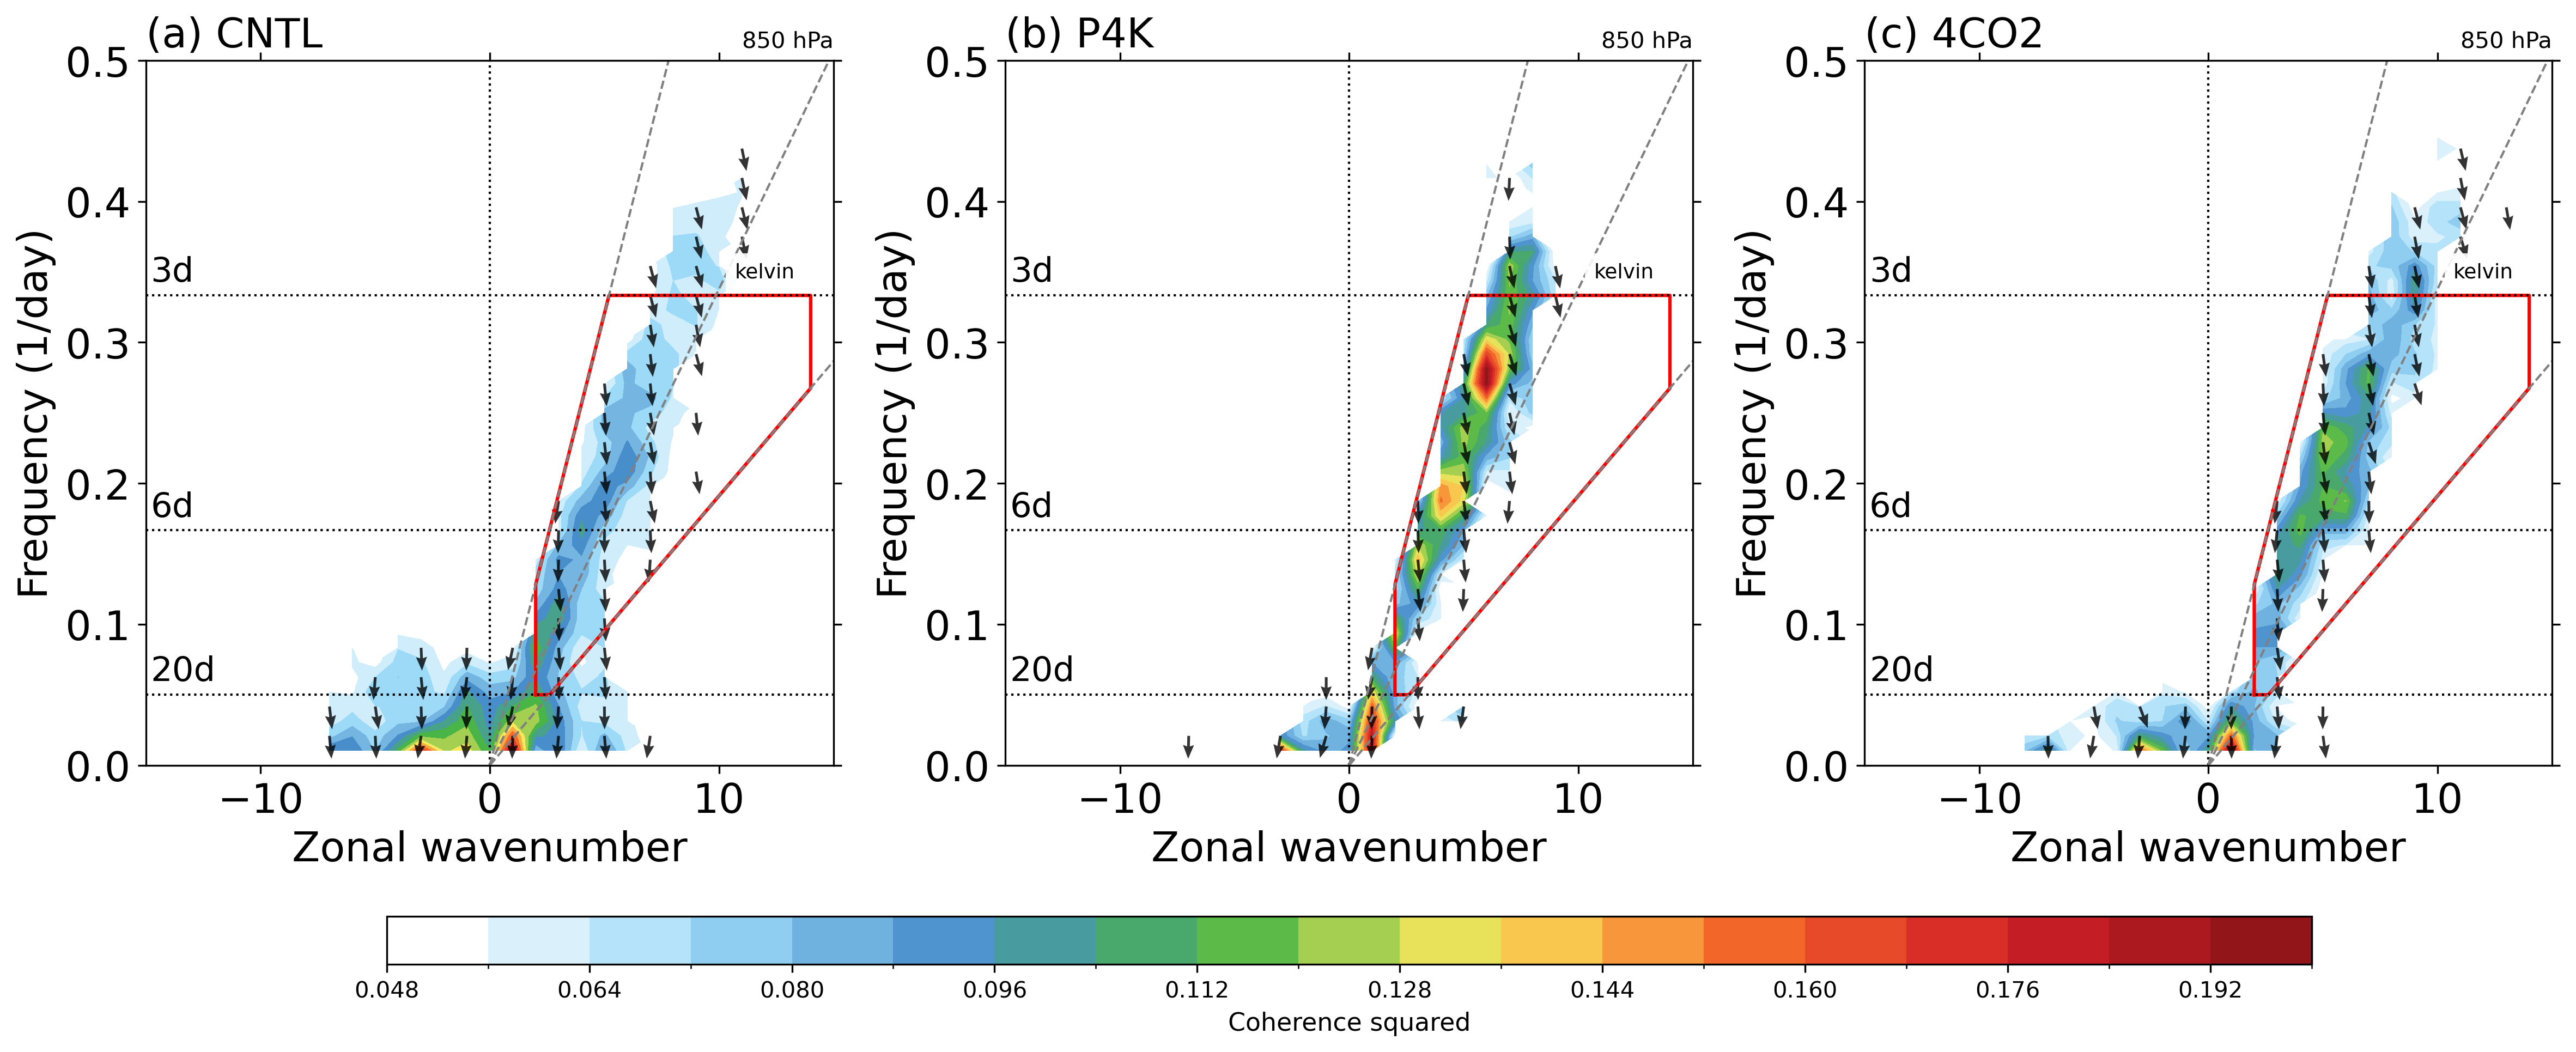


✅ 所有气压层的图片生成完成！


In [45]:
# ============ 为所有气压层生成指定样式的交叉谱图 ============
coh2_threshold = 0.05
# 循环处理所有气压层
for PLEV in [850]:
    print(f"\n{'='*60}")
    print(f"绘制 {PLEV} hPa 气压层的交叉谱图")
    print(f"{'='*60}")
    
    # 创建3个子图
    fig, axes = plt.subplots(1, 3, figsize=(16, 8), dpi=300)
    plt.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.15, wspace=0.25)
    plt.rcParams.update({'font.size': 10})

    for idx, (exp_name, exp_title, ax) in enumerate(zip(exp_names, exp_titles, axes)):
        plt.sca(ax)

        # 获取当前实验和气压层的结果
        stc = crossspectrum_results[exp_name][PLEV]['STC']
        zonalwnum = crossspectrum_results[exp_name][PLEV]['wave']
        freq = crossspectrum_results[exp_name][PLEV]['freq']

        # 获取coherence squared数据
        try:
            coh2_data = stc.sel(component='COH2')
        except:
            coh2_data = stc.isel(component=2)
        coh2_data_masked = coh2_data.where(coh2_data >= coh2_threshold)
        # 绘制coherence squared的等高线图
        contourf = coh2_data_masked.plot.contourf(
            ax=ax,
            cmap=cmaps.WhiteBlueGreenYellowRed,
            levels=21,
            add_colorbar=False,
            add_labels=False,
            extend='neither'
        )

        # 准备矢量场数据
        skip = 2
        wave_sub = zonalwnum[::skip]
        freq_sub = freq[::skip]
        
        # 获取V1和V2分量
        try:
            u_sub = stc.sel(component='V1').values[::skip, ::skip]
            v_sub = stc.sel(component='V2').values[::skip, ::skip]
            coh2_sub = stc.sel(component='COH2').values[::skip, ::skip]
        except:
            u_sub = stc.isel(component=0).values[::skip, ::skip]
            v_sub = stc.isel(component=1).values[::skip, ::skip]
            coh2_sub = stc.isel(component=2).values[::skip, ::skip]

        # 创建掩蔽
        mask = coh2_sub < coh2_threshold
        u_masked = np.where(mask, np.nan, u_sub)
        v_masked = np.where(mask, np.nan, v_sub)

        # 添加矢量场
        q = ax.quiver(
            wave_sub, freq_sub,
            u_masked, v_masked,
            scale=30, headwidth=4, headlength=5, 
            width=0.004, alpha=0.8
        )

        # 设置标题
        ax.set_title(f'({chr(97 + idx)}) {exp_title}', fontsize=18, loc='left')
        ax.set_title(f'{PLEV} hPa', fontsize=10, loc='right')

        # 设置坐标轴
        ax.set_ylabel('Frequency (1/day)', fontsize=18)
        ax.set_xlabel('Zonal wavenumber', fontsize=18)
        ax.set_xlim(-15, 15)
        ax.set_ylim(0, 0.5)
        
        # 绘制CCKW波段
        
        kw_x, kw_y = get_cckw_envelope_curve()  # 不传参数，使用默认值
       
        ax.plot(kw_x[0], kw_y[0], 'red', linewidth=1.5, linestyle='solid', label='CCKW band')

        
        # 添加参考线
        d = np.array([3, 6, 20])
        dname = ['3d', '6d', '20d']
        he_all = np.array([8, 25, 90])
        cp = (9.8 * he_all) ** 0.5
        zwnum_goal = 0.5 / s2d / cp * 2 * np.pi * re

        # 零波数线
        ax.plot([0, 0], [0, 0.5], 'k', linewidth=1, linestyle=':')

        # 周期线
        for dd in range(len(d)):
            ax.plot([-15, 15], [1/d[dd], 1/d[dd]], 'k', linewidth=1, linestyle=':')
            ax.text(-14.8, 1/d[dd] + 0.01, dname[dd], fontsize=15, color='k')

        # Kelvin波色散关系
        for hh in range(len(he_all)):
            ax.plot([0, zwnum_goal[hh]], [0, 0.5], 'grey', linewidth=1, linestyle='dashed')

        # 添加"kelvin"标签
        ax.text(12, 0.35, 'kelvin', ha="center", va="center", size=9,
                bbox={'facecolor': 'w', 'alpha': 0.9, 'edgecolor': 'none'})
        ax.tick_params(labelsize=18, which='both', top=True, right=True)

    # 添加颜色条
    cbar = fig.colorbar(contourf, ax=axes, orientation='horizontal', 
                        pad=0.15, aspect=40, shrink=0.8)
    cbar.set_label(r'Coherence squared', fontsize=11)

    # 保存图片
    output_filename = f'{FIG_SAVE_DIR}cross_spectrum_pr_div_{PLEV}hpa_95%.png'
    fig.savefig(output_filename, bbox_inches='tight')
    print(f"✅ 图片已保存: {output_filename}")
    
    plt.show()
    plt.close(fig)

print("\n" + "="*60)
print("✅ 所有气压层的图片生成完成！")
print("="*60)


绘制 250 hPa 气压层的交叉谱图 (99%显著性检验)
  CNTL - 250 hPa: 99%显著性阈值 = 0.020437
     通过99%显著性检验的点数: 3072/8183
     有效的矢量数: 737
  P4K - 250 hPa: 99%显著性阈值 = 0.020437
     通过99%显著性检验的点数: 1443/8183
     有效的矢量数: 341
  4CO2 - 250 hPa: 99%显著性阈值 = 0.020437
     通过99%显著性检验的点数: 2725/8183
     有效的矢量数: 678


✅ 图片已保存: /work/mh1498/m301257/figures/cross_spectrum_pr_div_250hpa_99%_corrected.png


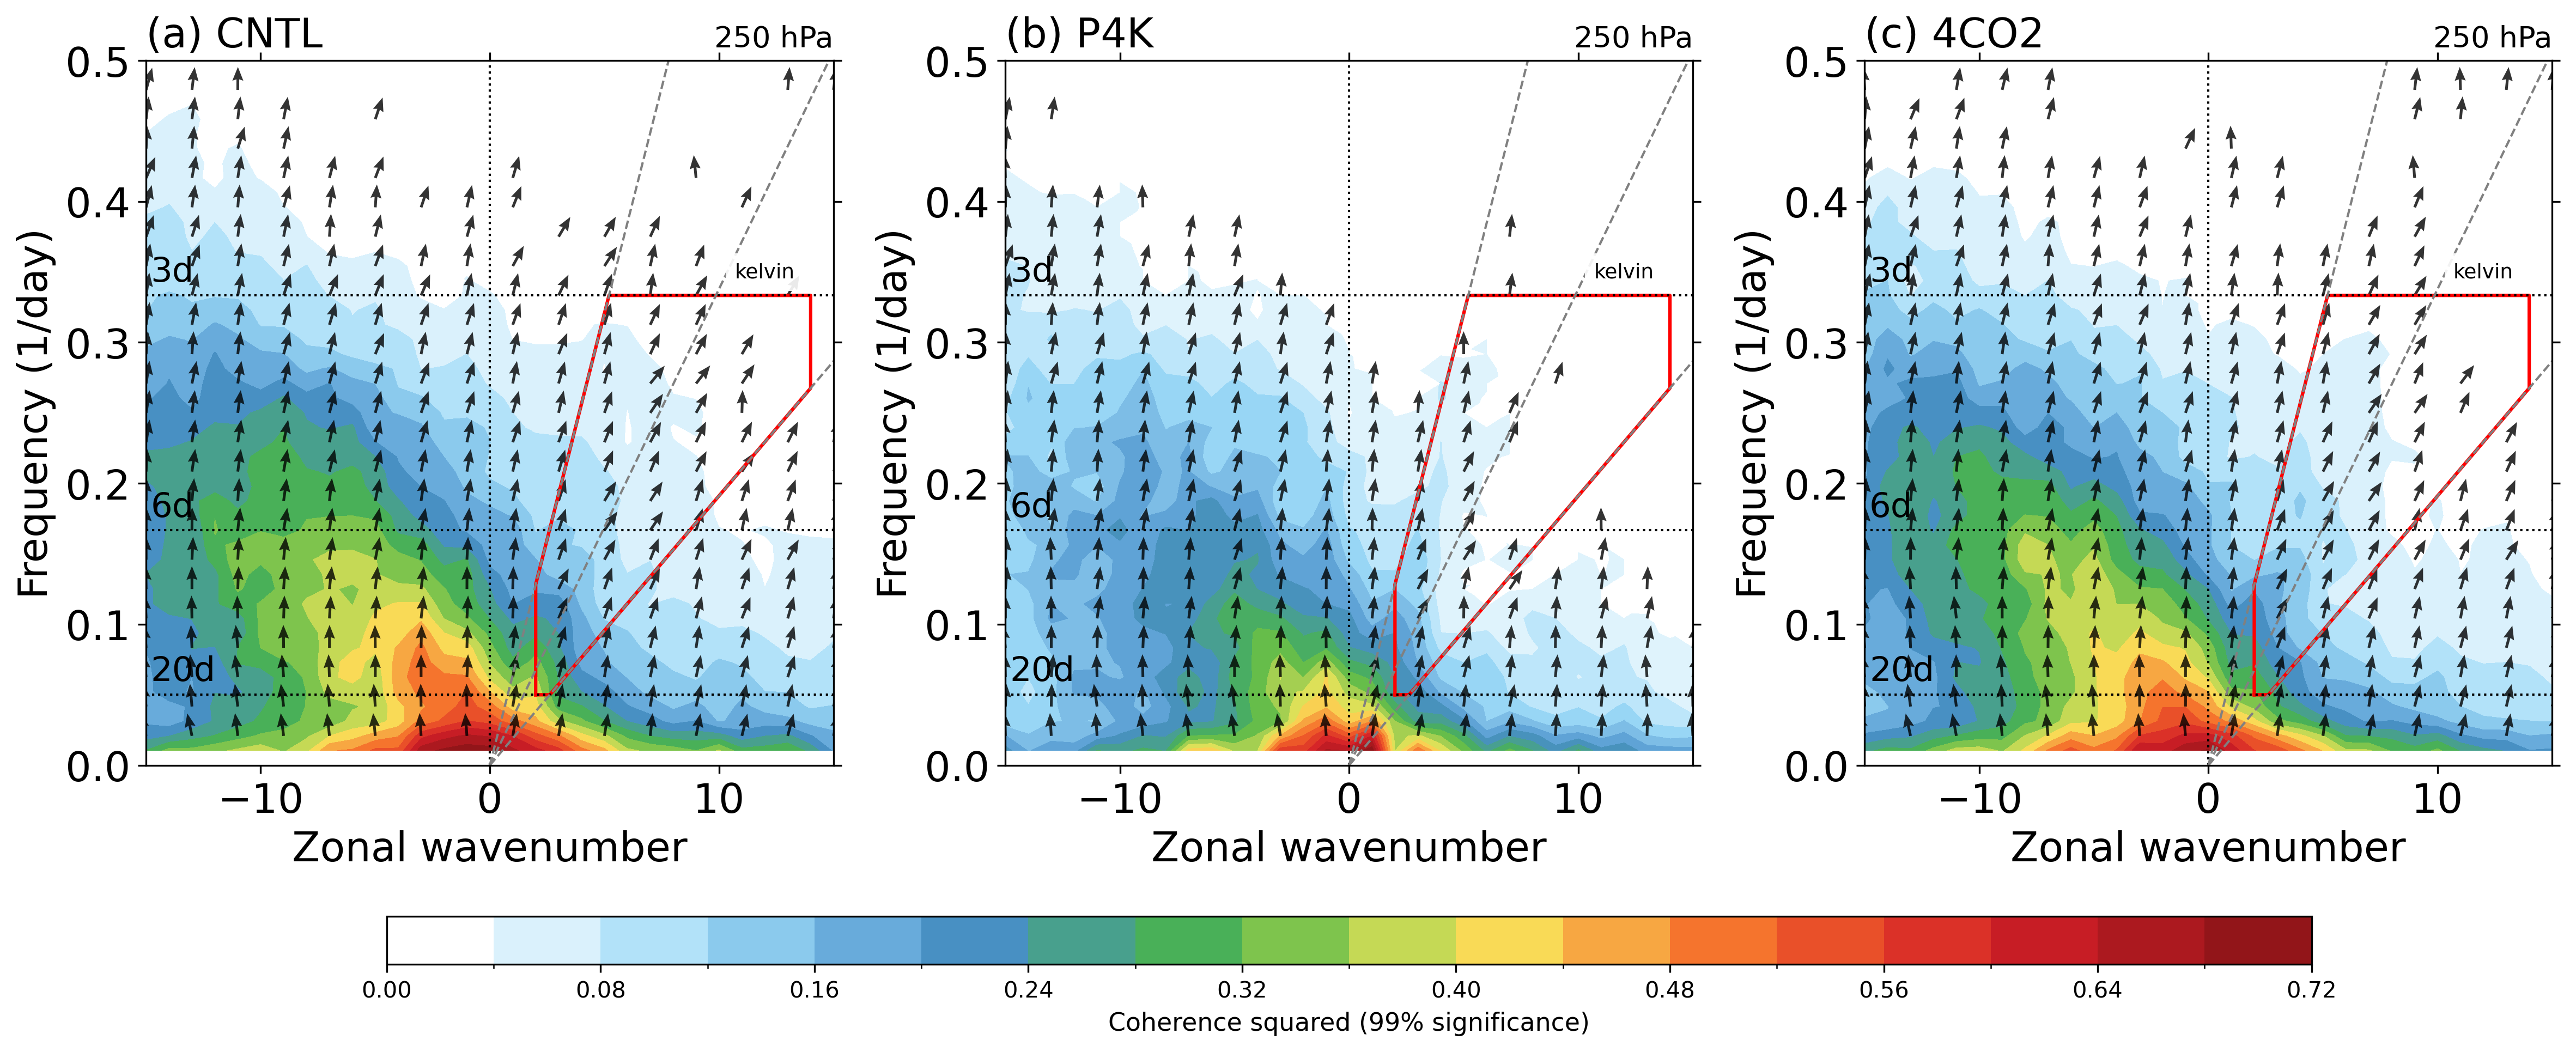


绘制 500 hPa 气压层的交叉谱图 (99%显著性检验)
  CNTL - 500 hPa: 99%显著性阈值 = 0.020437
     通过99%显著性检验的点数: 240/8183
     有效的矢量数: 56
  P4K - 500 hPa: 99%显著性阈值 = 0.020437
     通过99%显著性检验的点数: 249/8183
     有效的矢量数: 58
  4CO2 - 500 hPa: 99%显著性阈值 = 0.020437
     通过99%显著性检验的点数: 288/8183
     有效的矢量数: 64
✅ 图片已保存: /work/mh1498/m301257/figures/cross_spectrum_pr_div_500hpa_99%_corrected.png
✅ 图片已保存: /work/mh1498/m301257/figures/cross_spectrum_pr_div_500hpa_99%_corrected.png


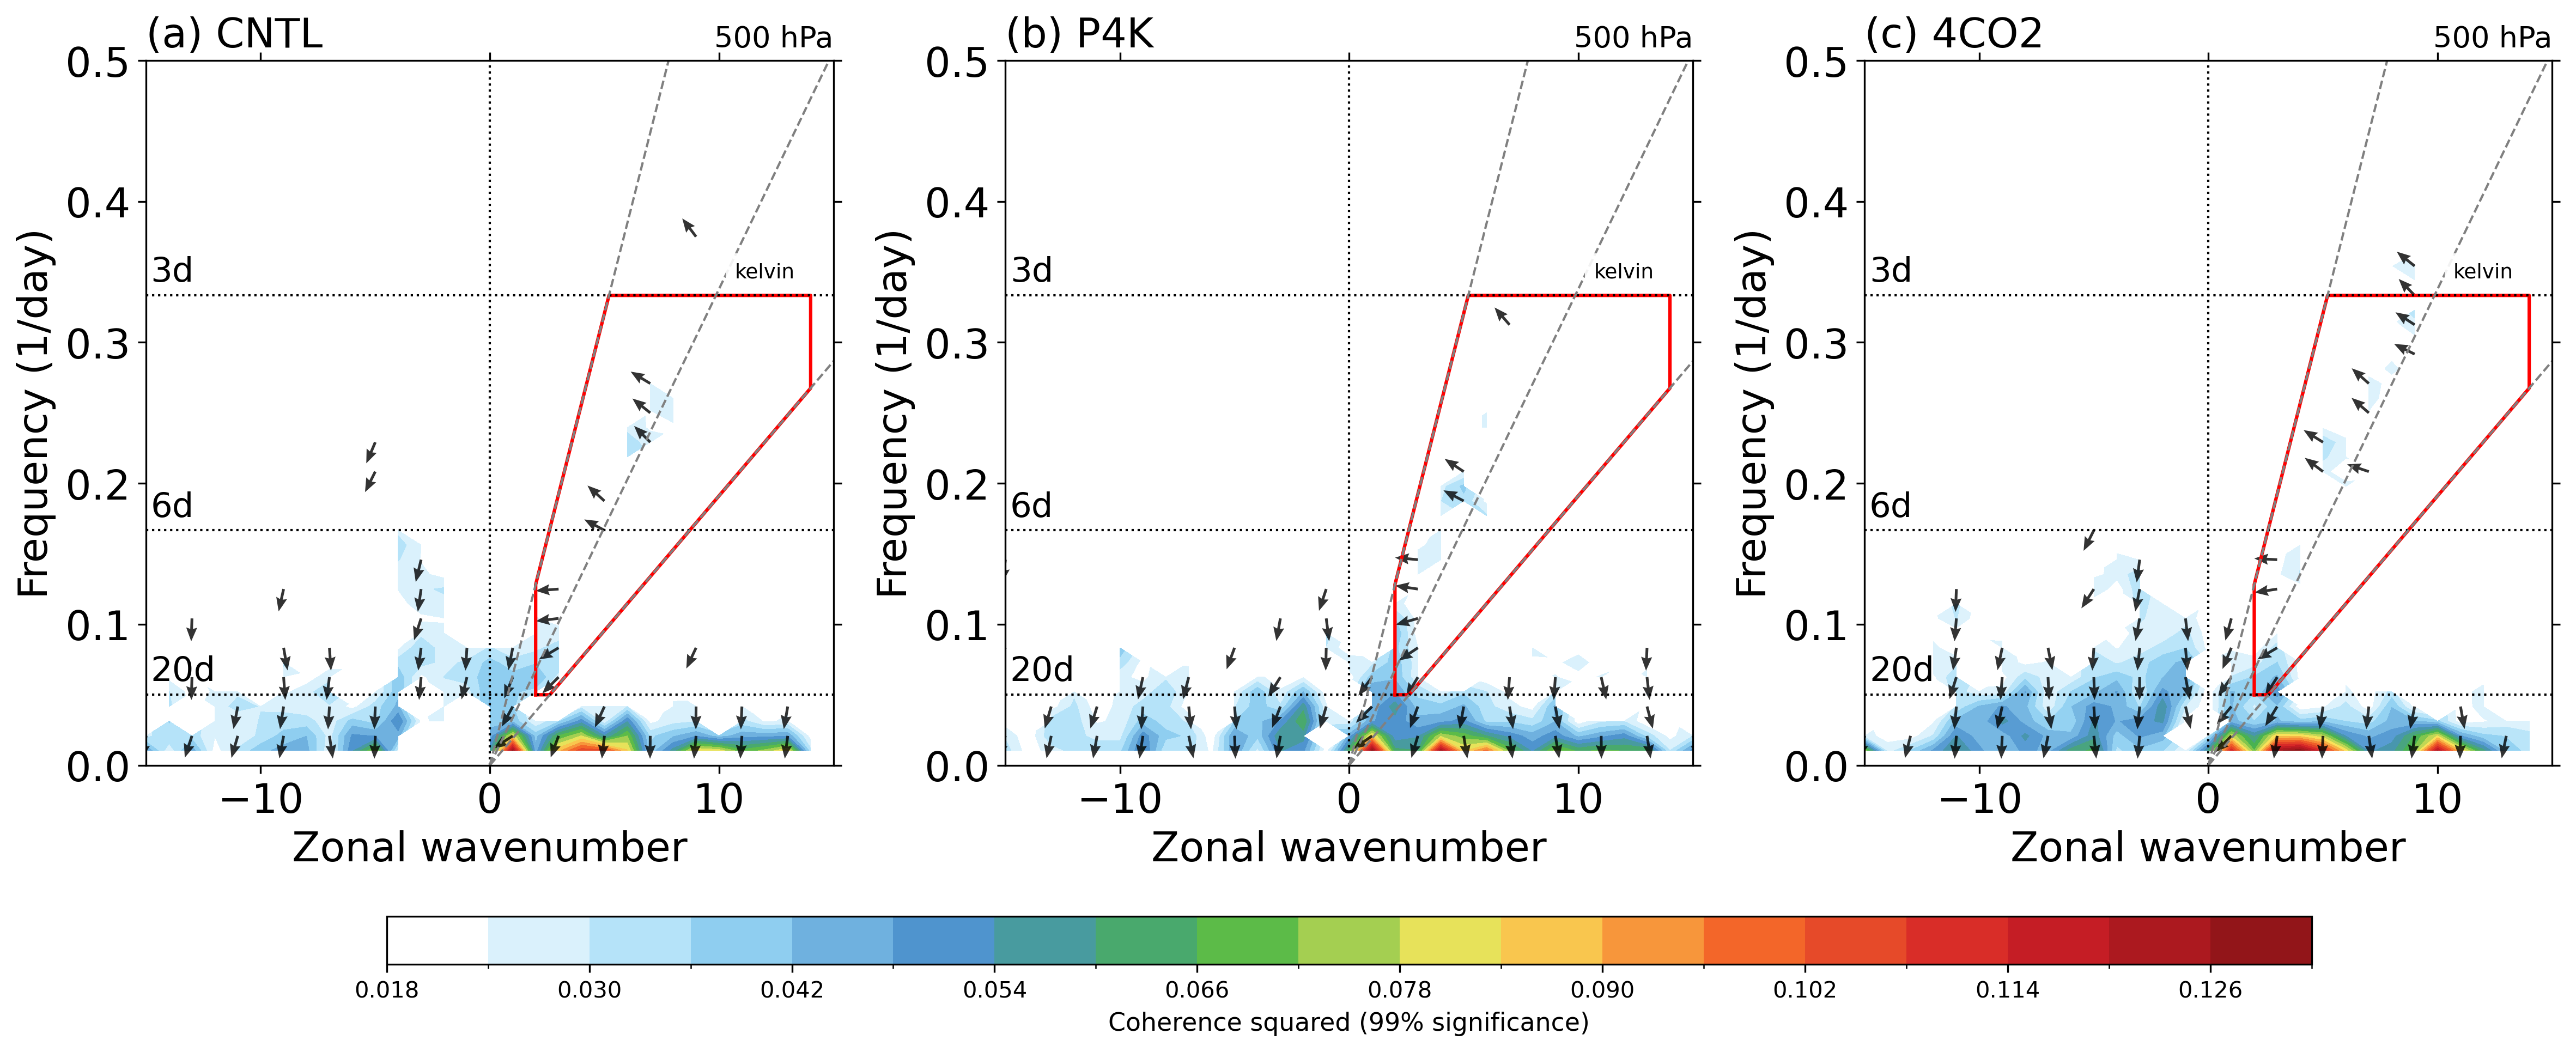


绘制 850 hPa 气压层的交叉谱图 (99%显著性检验)
  CNTL - 850 hPa: 99%显著性阈值 = 0.020437
     通过99%显著性检验的点数: 845/8183
     有效的矢量数: 203
  P4K - 850 hPa: 99%显著性阈值 = 0.020437
     通过99%显著性检验的点数: 564/8183
     有效的矢量数: 143
  4CO2 - 850 hPa: 99%显著性阈值 = 0.020437
     通过99%显著性检验的点数: 727/8183
     有效的矢量数: 186
✅ 图片已保存: /work/mh1498/m301257/figures/cross_spectrum_pr_div_850hpa_99%_corrected.png
✅ 图片已保存: /work/mh1498/m301257/figures/cross_spectrum_pr_div_850hpa_99%_corrected.png


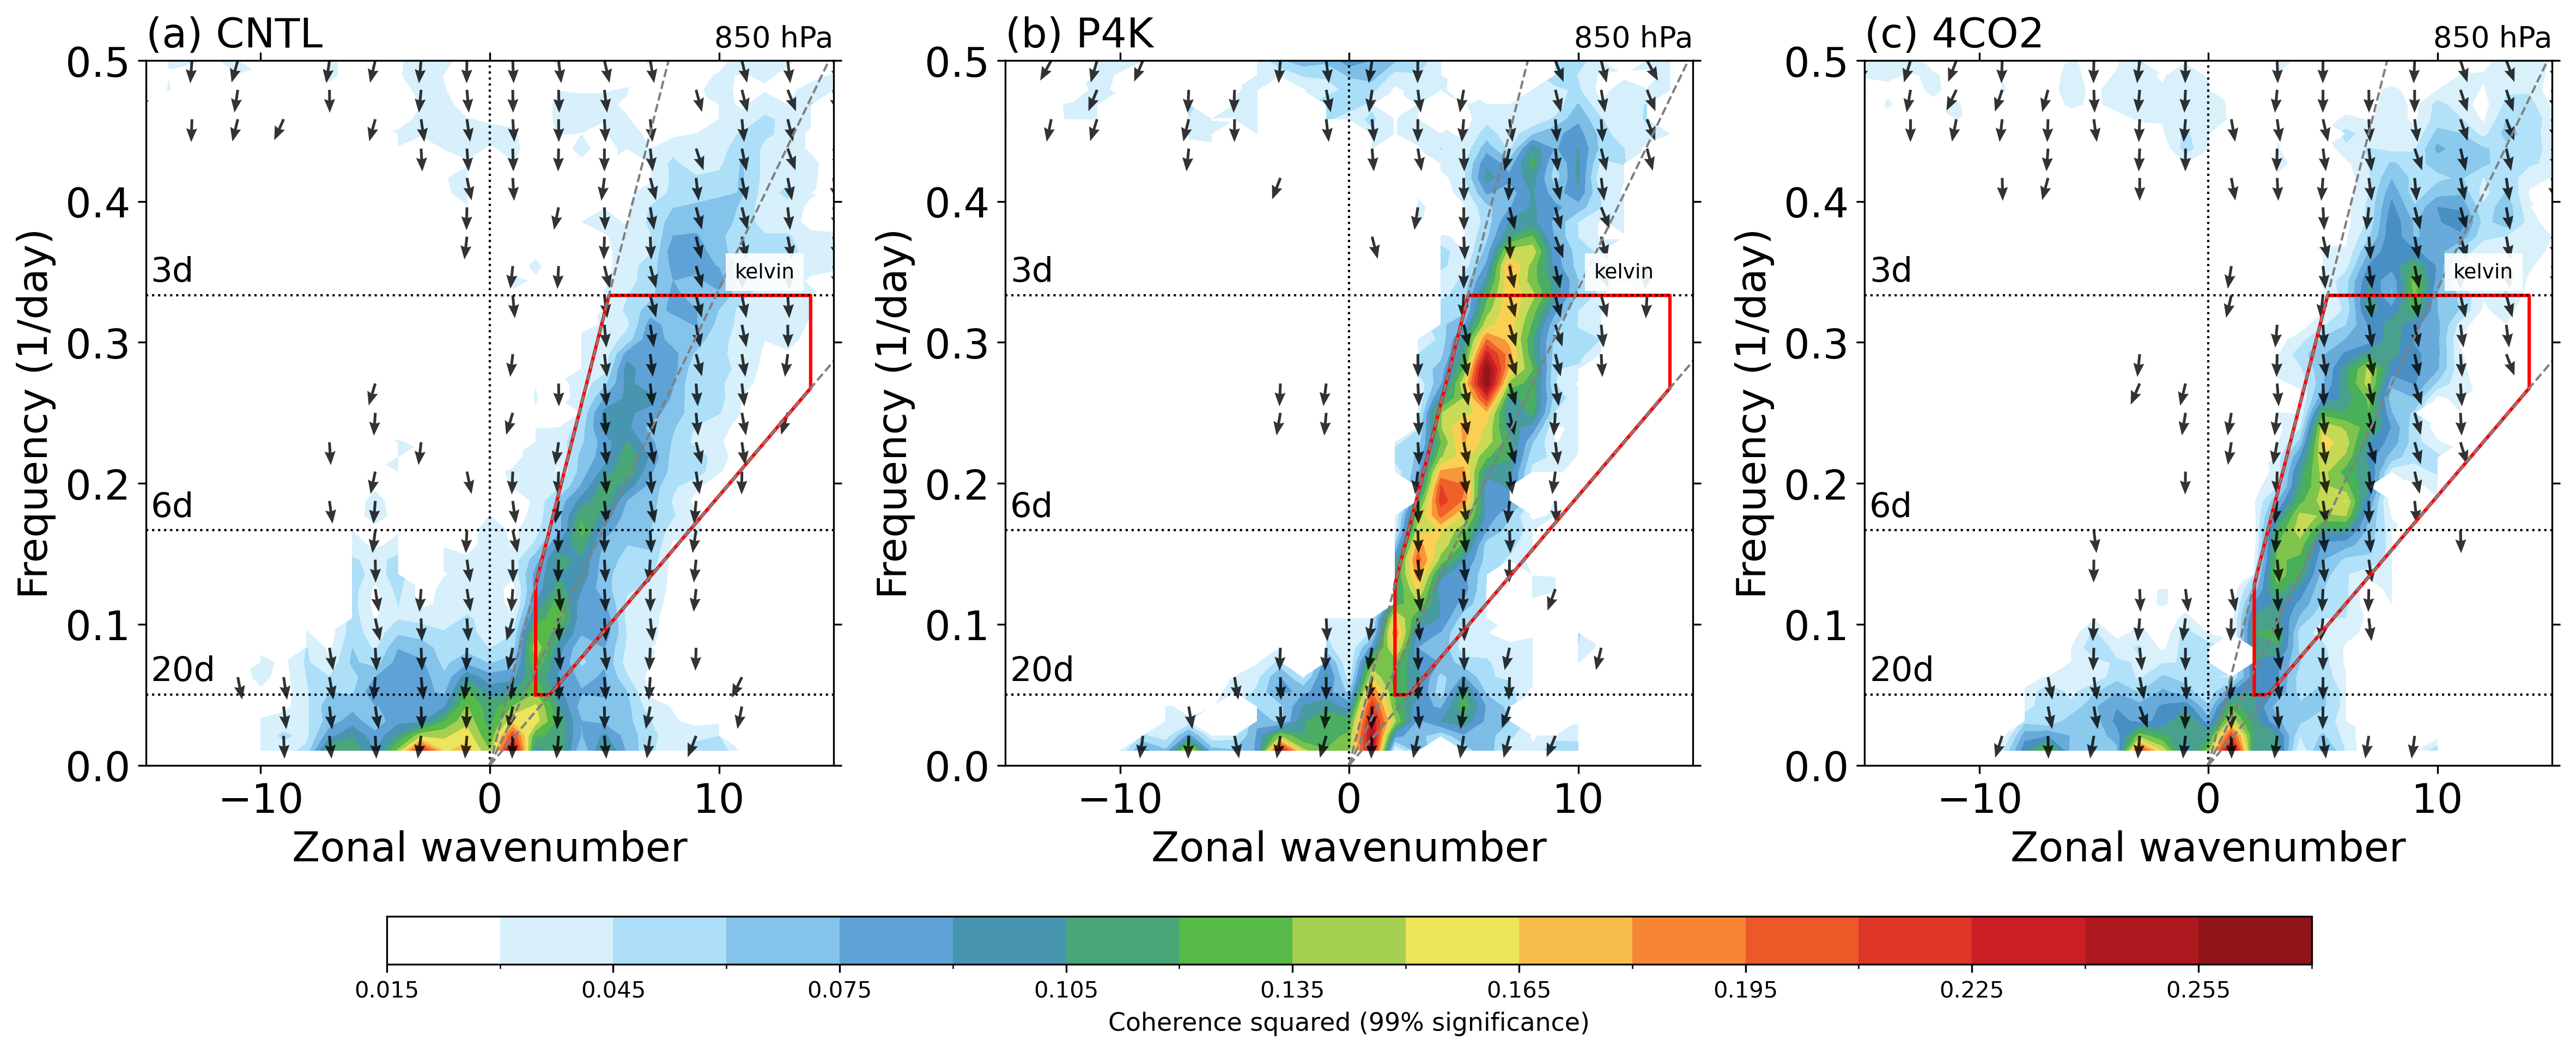


✅ 所有气压层的图片生成完成（使用正确的99%显著性检验）！


In [58]:
# ============ 正确使用99%显著性检验的绘图代码 ============

# 循环处理所有气压层
for PLEV in [250, 500, 850]:
    print(f"\n{'='*60}")
    print(f"绘制 {PLEV} hPa 气压层的交叉谱图 (99%显著性检验)")
    print(f"{'='*60}")
    
    # 创建3个子图
    fig, axes = plt.subplots(1, 3, figsize=(16, 8), dpi=300)
    plt.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.15, wspace=0.25)
    plt.rcParams.update({'font.size': 10})

    # 用于存储contourf对象，以便添加colorbar
    contourf_list = []
    
    for idx, (exp_name, exp_title, ax) in enumerate(zip(exp_names, exp_titles, axes)):
        plt.sca(ax)

        # 获取当前实验和气压层的结果
        stc = crossspectrum_results[exp_name][PLEV]['STC']
        zonalwnum = crossspectrum_results[exp_name][PLEV]['wave']
        freq = crossspectrum_results[exp_name][PLEV]['freq']
        
        # 🔑 关键：获取99%置信水平的临界值
        coh2_99_threshold_array = crossspectrum_results[exp_name][PLEV]['prob_coh2']
        
        # 如果是数组，取最大值（最保守的检验）
        if isinstance(coh2_99_threshold_array, np.ndarray) and coh2_99_threshold_array.size > 1:
            coh2_99_threshold = float(coh2_99_threshold_array.max())
        elif hasattr(coh2_99_threshold_array, 'item'):
            coh2_99_threshold = float(coh2_99_threshold_array.item())
        else:
            coh2_99_threshold = float(coh2_99_threshold_array)
        
        print(f"  {exp_name.upper()} - {PLEV} hPa: 99%显著性阈值 = {coh2_99_threshold:.6f}")

        # 获取coherence squared数据
        try:
            coh2_data = stc.sel(component='COH2')
        except:
            coh2_data = stc.isel(component=2)
        
        # 检查有多少点通过显著性检验
        n_significant = int((coh2_data >= coh2_99_threshold).sum())
        print(f"     通过99%显著性检验的点数: {n_significant}/{coh2_data.size}")
        
        # 🔑 使用99%置信水平阈值进行掩蔽
        coh2_data_masked = coh2_data.where(coh2_data >= coh2_99_threshold)
        
        # 绘制coherence squared的等高线图
        try:
            contourf = coh2_data_masked.plot.contourf(
                ax=ax,
                cmap=cmaps.WhiteBlueGreenYellowRed,
                levels=21,
                add_colorbar=False,
                add_labels=False,
                extend='neither'
            )
            contourf_list.append(contourf)
        except Exception as e:
            print(f"     ⚠️  警告: 无法绘制等高线图 - {e}")
            # 如果等高线图失败，尝试使用pcolormesh
            try:
                contourf = ax.pcolormesh(
                    zonalwnum, freq, coh2_data_masked,
                    cmap=cmaps.WhiteBlueGreenYellowRed,
                    shading='auto'
                )
                contourf_list.append(contourf)
            except Exception as e2:
                print(f"     ❌ 错误: 也无法绘制pcolormesh - {e2}")

        # 准备矢量场数据
        skip = 2
        wave_sub = zonalwnum[::skip]
        freq_sub = freq[::skip]
        
        # 获取V1和V2分量
        try:
            u_sub = stc.sel(component='V1').values[::skip, ::skip]
            v_sub = stc.sel(component='V2').values[::skip, ::skip]
            coh2_sub = stc.sel(component='COH2').values[::skip, ::skip]
        except:
            u_sub = stc.isel(component=0).values[::skip, ::skip]
            v_sub = stc.isel(component=1).values[::skip, ::skip]
            coh2_sub = stc.isel(component=2).values[::skip, ::skip]

        # 🔑 使用99%置信水平阈值掩蔽矢量场
        mask = coh2_sub < coh2_99_threshold
        u_masked = np.where(mask, np.nan, u_sub)
        v_masked = np.where(mask, np.nan, v_sub)

        # 检查是否有有效的矢量
        n_valid_vectors = np.sum(~np.isnan(u_masked))
        print(f"     有效的矢量数: {n_valid_vectors}")

        # 添加矢量场（只有在有有效矢量时）
        if n_valid_vectors > 0:
            try:
                q = ax.quiver(
                    wave_sub, freq_sub,
                    u_masked, v_masked,
                    scale=30, headwidth=4, headlength=5, 
                    width=0.004, alpha=0.8
                )
            except Exception as e:
                print(f"     ⚠️  警告: 无法绘制矢量场 - {e}")

        # 设置标题
        ax.set_title(f'({chr(97 + idx)}) {exp_title}', fontsize=18, loc='left')
        ax.set_title(f'{PLEV} hPa', fontsize=13, loc='right')

        # 设置坐标轴
        ax.set_ylabel('Frequency (1/day)', fontsize=18)
        ax.set_xlabel('Zonal wavenumber', fontsize=18)
        ax.set_xlim(-15, 15)
        ax.set_ylim(0, 0.5)
        
        # 绘制CCKW波段
        kw_x, kw_y = get_cckw_envelope_curve()
        ax.plot(kw_x[0], kw_y[0], 'red', linewidth=1.5, linestyle='solid', label='CCKW band')
        
        # 添加参考线
        d = np.array([3, 6, 20])
        dname = ['3d', '6d', '20d']
        he_all = np.array([8, 25, 90])
        cp = (9.8 * he_all) ** 0.5
        zwnum_goal = 0.5 / s2d / cp * 2 * np.pi * re

        # 零波数线
        ax.plot([0, 0], [0, 0.5], 'k', linewidth=1, linestyle=':')

        # 周期线
        for dd in range(len(d)):
            ax.plot([-15, 15], [1/d[dd], 1/d[dd]], 'k', linewidth=1, linestyle=':')
            ax.text(-14.8, 1/d[dd] + 0.01, dname[dd], fontsize=15, color='k')

        # Kelvin波色散关系
        for hh in range(len(he_all)):
            ax.plot([0, zwnum_goal[hh]], [0, 0.5], 'grey', linewidth=1, linestyle='dashed')

        # 添加"kelvin"标签
        ax.text(12, 0.35, 'kelvin', ha="center", va="center", size=9,
                bbox={'facecolor': 'w', 'alpha': 0.9, 'edgecolor': 'none'})
        ax.tick_params(labelsize=18, which='both', top=True, right=True)

    # 添加颜色条（如果有成功的contourf对象）
    if contourf_list:
        cbar = fig.colorbar(contourf_list[0], ax=axes, orientation='horizontal', 
                            pad=0.15, aspect=40, shrink=0.8)
        cbar.set_label(r'Coherence squared (99% significance)', fontsize=11)

    # 保存图片
    output_filename = f'{FIG_SAVE_DIR}cross_spectrum_pr_div_{PLEV}hpa_99%_corrected.png'
    fig.savefig(output_filename, bbox_inches='tight', dpi=300)
    print(f"✅ 图片已保存: {output_filename}")
    
    plt.show()
    plt.close(fig)

print("\n" + "="*60)
print("✅ 所有气压层的图片生成完成（使用正确的99%显著性检验）！")
print("="*60)